In [1]:
import os
import pathlib

# check all artifacts folders where there is a "submission.csv" file

def find_submission_csv_files(root_dir):
    submission_csv_files = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if "submission.csv" in filenames:
            submission_csv_files.append(os.path.join(dirpath, "submission.csv"))
    return submission_csv_files

# get all the submissionscsv files in the current directory and its subdirectories
# this is a jupyter notebook, so we can use the current working directory
current_dir = pathlib.Path().resolve()
submission_csv_files = find_submission_csv_files(current_dir)
print("Found the following submission.csv files:")
for file in submission_csv_files:   
    print(file)

Found the following submission.csv files:
C:\Users\mario\OneDrive\Documentos\UPM\Master_Data\Sistemas_recomendacion\recomendation-system\content-based\artifacts\artifact_submission_ensemble_smoke\submission.csv
C:\Users\mario\OneDrive\Documentos\UPM\Master_Data\Sistemas_recomendacion\recomendation-system\content-based\artifacts\artifact_submission_ensemble_v1\submission.csv
C:\Users\mario\OneDrive\Documentos\UPM\Master_Data\Sistemas_recomendacion\recomendation-system\content-based\artifacts\blended_submission_v1\submission.csv
C:\Users\mario\OneDrive\Documentos\UPM\Master_Data\Sistemas_recomendacion\recomendation-system\content-based\artifacts\frozen_embedding_submission_v1\submission.csv
C:\Users\mario\OneDrive\Documentos\UPM\Master_Data\Sistemas_recomendacion\recomendation-system\content-based\artifacts\gbm_submission_v1\submission.csv
C:\Users\mario\OneDrive\Documentos\UPM\Master_Data\Sistemas_recomendacion\recomendation-system\content-based\artifacts\known_user_deep_router_moe_eval

In [30]:
import pandas as pd

# for submission in submission_csv_files:
#     print(f"Comparing {submission} with the others...")
#     for other_submission in submission_csv_files:
#         if submission != other_submission:
#             print(f"Comparing {submission} with {other_submission}...")
#             # here we can add code to compare the two submission.csv files, for example by reading them into pandas dataframes and comparing the values
#             df1 = pd.read_csv(submission)
#             df2 = pd.read_csv(other_submission)
#             # get the differences between the two dataframes
#             differences = df1.compare(df2)

            # print(f"Differences between {submission} and {other_submission}:")
            # print(differences)


# make a dataframe with all the rows of all the submission.csv files, and add a column for each submission with the value of the submission file for that row. The column name should be the name of the submission file. This way we can easily compare the values of each submission for each row.
all_submissions_df = pd.DataFrame()

for submission in submission_csv_files:
    df = pd.read_csv(submission)
    model_name = os.path.basename(os.path.dirname(submission))
    df = df.rename(columns={"stars": model_name}) # rename the rating column to the name of the submission file
    if all_submissions_df.empty:
        all_submissions_df = df
    else:
        all_submissions_df = pd.concat([all_submissions_df, df], axis=1)

# there are some duplicated columns, we can remove them
all_submissions_df = all_submissions_df.loc[:,~all_submissions_df.columns.duplicated()]

all_submissions_df


,review_id,artifact_submission_ensemble_smoke,artifact_submission_ensemble_v1,blended_submission_v1,frozen_embedding_submission_v1,gbm_submission_v1,known_user_deep_router_moe_eval_v1,known_user_deep_router_v1,known_user_deep_router_v2_eval_v2,known_user_deep_router_v2_eval_v3,...,lgbm_deep_embeddings_submission_v1,lgbm_feature_first_short_router_v2_gpu_conservative,lgbm_hybrid_conservative_v1,lgbm_raw_core_v1,lgbm_raw_priors_v1,lgbm_raw_router_prefix_deep_v1,lgbm_raw_router_v1,meta_lgbm_hybrid_v1,meta_lgbm_hybrid_v2,meta_lgbm_hybrid_v3
0,ieYPmCImINjPzTDFmEKBKA,5,5,5,4,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
1,QIkJ8fZ4yx_QaHahWWszAA,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
2,seR2KhblYMWg-k9zzN6aYA,2,2,1,1,1,2,2,2,3,...,1,2,2,2,1,2,2,3,3,3
3,BToo00Fi5pfJFA5MI2HM5g,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,5,4
4,FHJAzi1imodBit3RWK7zQA,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414760,5VF1OSReEKAJS3z7lc0VRg,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,5,5,5
414761,N_yTSNrcGzGUSFPyIhAZ-g,5,5,4,4,4,5,5,5,5,...,4,5,5,5,4,5,5,4,4,4
414762,zQLW0mkqDtmseg8pl-zbNA,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
414763,DspB5yysBWRlFe01j_LzeA,5,5,4,4,4,5,5,5,5,...,4,5,5,5,5,5,5,4,4,4


Text(0.5, 0, 'Max difference between submissions')

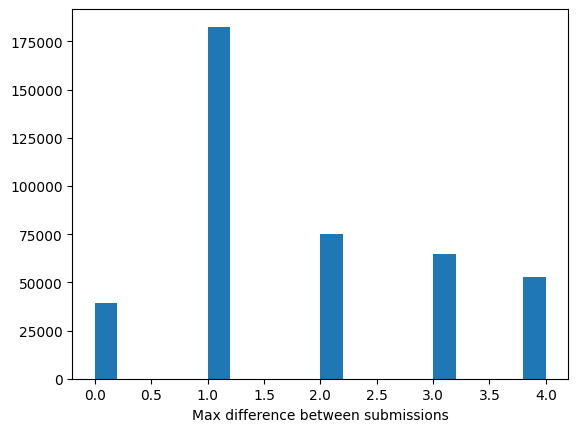

In [31]:
import matplotlib.pyplot as plt

all_submissions_df['max_diff'] = all_submissions_df.iloc[:, 1:].max(axis=1) - all_submissions_df.iloc[:, 1:].min(axis=1)

plt.hist(all_submissions_df['max_diff'], bins=20)
plt.xlabel('Max difference between submissions')

<Axes: >

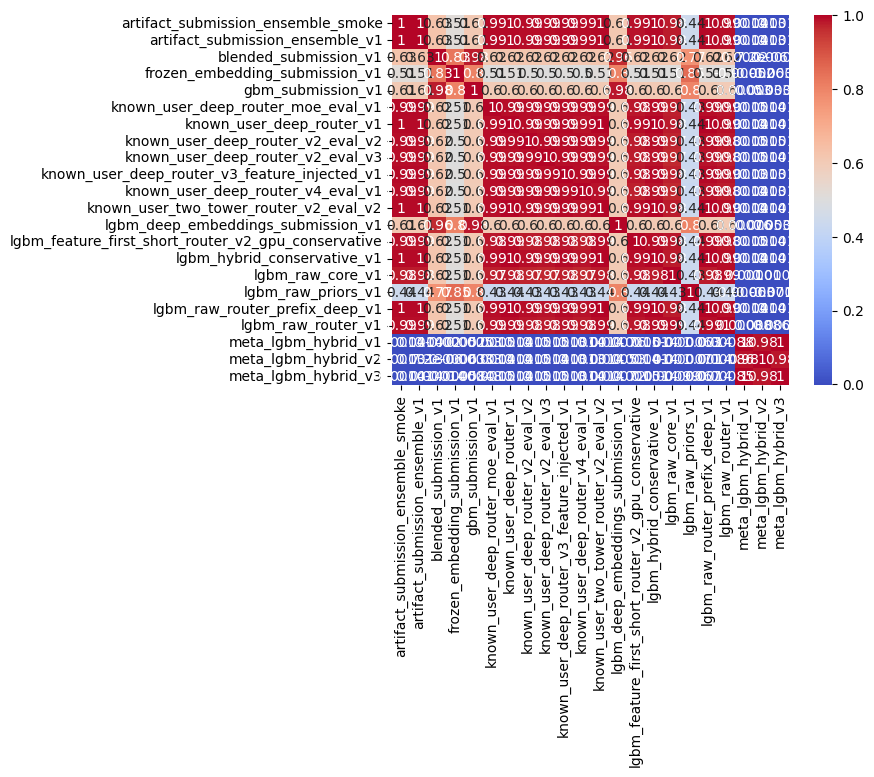

In [32]:
import seaborn as sns

sns.heatmap(all_submissions_df.iloc[:, 1:-1].corr(), annot=True, cmap='coolwarm')


In [33]:
selected_models = [
    "known_user_deep_router_moe_eval_v1",
    "meta_lgbm_hybrid_v1",
    "meta_lgbm_hybrid_v3",
    "lgbm_raw_priors_v1"
]

# compute the overlap between the selected models, that is, the number of rows where all the selected models have the same value
overlap = all_submissions_df[selected_models].nunique(axis=1) == 1

print(f"Overlap between the selected models: {overlap.sum() / len(all_submissions_df)} %")

Overlap between the selected models: 0.1495569780478102 %


In [ ]:
import pandas as pd
import numpy as np
from typing import List, Optional, Literal, Dict


class SubmissionBlender:
    """
    Blender para submissions con predicciones discretas de estrellas (1..5).

    Pensado para casos donde:
    - hay varias columnas de modelos
    - no hay validación local fuerte
    - interesa una mezcla robusta y explicable

    Parámetros
    ----------
    model_cols : list[str]
        Columnas del DataFrame que contienen las predicciones de los modelos.

    id_cols : list[str] | None
        Columnas identificadoras para exportar submission.
        Ej: ["Id"] o las que correspondan.

    base_model : str | None
        Modelo principal a usar como fallback en empates o conflictos.
        Muy recomendable pasar uno.

    majority_threshold : int
        Número mínimo de votos para considerar mayoría clara.
        Con 4 modelos: 3
        Con 3 modelos: 2
        Con 5 modelos: 3

    conflict_diff_threshold : int
        Diferencia máxima a partir de la cual consideramos conflicto fuerte.
        Para estrellas 1..5, un valor natural es 4.

    tie_strategy : {"base_model", "median", "mean_round"}
        Qué hacer cuando no hay mayoría clara.

    strong_conflict_strategy : {"base_model", "median", "mean_round", "mode"}
        Qué hacer cuando hay conflicto fuerte.

    clip_range : tuple[int, int]
        Rango válido de estrellas.
    """

    def __init__(
        self,
        model_cols: List[str],
        id_cols: Optional[List[str]] = None,
        base_model: Optional[str] = None,
        majority_threshold: Optional[int] = None,
        conflict_diff_threshold: int = 4,
        tie_strategy: Literal["base_model", "median", "mean_round"] = "base_model",
        strong_conflict_strategy: Literal["base_model", "median", "mean_round", "mode"] = "base_model",
        clip_range=(1, 5),
    ):
        self.model_cols = model_cols
        self.id_cols = id_cols or []
        self.base_model = base_model
        self.conflict_diff_threshold = conflict_diff_threshold
        self.tie_strategy = tie_strategy
        self.strong_conflict_strategy = strong_conflict_strategy
        self.clip_range = clip_range

        if majority_threshold is None:
            self.majority_threshold = len(model_cols) // 2 + 1
        else:
            self.majority_threshold = majority_threshold

        if self.tie_strategy == "base_model" and self.base_model is None:
            raise ValueError("Si tie_strategy='base_model', debes indicar base_model.")

        if self.strong_conflict_strategy == "base_model" and self.base_model is None:
            raise ValueError("Si strong_conflict_strategy='base_model', debes indicar base_model.")

        self.summary_: Optional[Dict] = None

    def _validate_input(self, df: pd.DataFrame):
        missing = [c for c in self.model_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas de modelos en el DataFrame: {missing}")

        if self.base_model is not None and self.base_model not in df.columns:
            raise ValueError(f"base_model='{self.base_model}' no existe en el DataFrame.")

        missing_ids = [c for c in self.id_cols if c not in df.columns]
        if missing_ids:
            raise ValueError(f"Faltan columnas identificadoras: {missing_ids}")

    @staticmethod
    def _safe_mode(values: pd.Series):
        vc = values.value_counts()
        top_count = vc.max()
        top_values = vc[vc == top_count].index.tolist()
        return min(top_values), int(top_count)

    def _compute_row_features(self, df: pd.DataFrame) -> pd.DataFrame:
        work = df.copy()
        preds = work[self.model_cols]

        work["blend_min"] = preds.min(axis=1)
        work["blend_max"] = preds.max(axis=1)
        work["blend_max_diff"] = work["blend_max"] - work["blend_min"]
        work["blend_mean"] = preds.mean(axis=1)
        work["blend_median"] = preds.median(axis=1)
        work["blend_n_unique"] = preds.nunique(axis=1)

        mode_values = []
        mode_counts = []

        for _, row in preds.iterrows():
            mode_val, mode_count = self._safe_mode(row)
            mode_values.append(mode_val)
            mode_counts.append(mode_count)

        work["blend_mode"] = mode_values
        work["blend_mode_count"] = mode_counts

        for star in range(self.clip_range[0], self.clip_range[1] + 1):
            work[f"votes_{star}"] = (preds == star).sum(axis=1)

        work["blend_has_majority"] = work["blend_mode_count"] >= self.majority_threshold
        work["blend_strong_conflict"] = work["blend_max_diff"] >= self.conflict_diff_threshold

        return work

    def _fallback_values(self, work: pd.DataFrame, strategy: str) -> pd.Series:
        if strategy == "base_model":
            return work[self.base_model]
        if strategy == "median":
            return work["blend_median"].round()
        if strategy == "mean_round":
            return work["blend_mean"].round()
        if strategy == "mode":
            return work["blend_mode"]
        raise ValueError(f"Estrategia no soportada: {strategy}")

    def transform(self, df: pd.DataFrame, output_col: str = "stars_blend") -> pd.DataFrame:
        self._validate_input(df)
        work = self._compute_row_features(df)

        # Base: donde hay mayoría clara, usamos la moda
        work[output_col] = work["blend_mode"]

        # Donde NO hay mayoría clara, aplicamos tie_strategy
        no_majority_mask = ~work["blend_has_majority"]
        work.loc[no_majority_mask, output_col] = self._fallback_values(
            work.loc[no_majority_mask], self.tie_strategy
        )

        # Donde además hay conflicto fuerte, aplicamos estrategia específica
        strong_conflict_mask = work["blend_strong_conflict"]
        work.loc[strong_conflict_mask, output_col] = self._fallback_values(
            work.loc[strong_conflict_mask], self.strong_conflict_strategy
        )

        work[output_col] = work[output_col].clip(*self.clip_range).astype(int)

        self.summary_ = {
            "n_rows": len(work),
            "n_no_majority": int(no_majority_mask.sum()),
            "n_strong_conflict": int(strong_conflict_mask.sum()),
            "pct_no_majority": float(no_majority_mask.mean()),
            "pct_strong_conflict": float(strong_conflict_mask.mean()),
            "majority_threshold": self.majority_threshold,
            "tie_strategy": self.tie_strategy,
            "strong_conflict_strategy": self.strong_conflict_strategy,
            "base_model": self.base_model,
        }

        return work

    def fit_transform(self, df: pd.DataFrame, output_col: str = "stars_blend") -> pd.DataFrame:
        return self.transform(df, output_col=output_col)

    def get_summary(self) -> Dict:
        if self.summary_ is None:
            raise ValueError("Primero ejecuta transform() o fit_transform().")
        return self.summary_

    def get_conflict_rows(
        self,
        df_blended: pd.DataFrame,
        min_diff: int = 4,
        no_majority_only: bool = False,
        sort_desc: bool = True,
    ) -> pd.DataFrame:
        required_cols = ["blend_max_diff", "blend_has_majority"]
        missing = [c for c in required_cols if c not in df_blended.columns]
        if missing:
            raise ValueError(f"El DataFrame no contiene columnas calculadas por el blender: {missing}")

        mask = df_blended["blend_max_diff"] >= min_diff
        if no_majority_only:
            mask &= ~df_blended["blend_has_majority"]

        cols = self.id_cols + self.model_cols + [
            "blend_mode", "blend_mode_count", "blend_median", "blend_mean",
            "blend_n_unique", "blend_max_diff", "blend_has_majority", "blend_strong_conflict"
        ]
        cols = [c for c in cols if c in df_blended.columns]

        out = df_blended.loc[mask, cols].copy()
        out = out.sort_values("blend_max_diff", ascending=not sort_desc)
        return out

    def export_submission(
        self,
        df_blended: pd.DataFrame,
        output_path: str,
        prediction_col: str = "stars_blend",
        target_name: str = "stars",
    ):
        if not self.id_cols:
            raise ValueError("Para exportar necesitas indicar id_cols al crear la clase.")

        required = self.id_cols + [prediction_col]
        missing = [c for c in required if c not in df_blended.columns]
        if missing:
            raise ValueError(f"Faltan columnas necesarias para exportar: {missing}")

        submission = df_blended[self.id_cols + [prediction_col]].copy()
        submission = submission.rename(columns={prediction_col: target_name})
        submission.to_csv(output_path, index=False)

submission_blender = SubmissionBlender(
    model_cols=selected_models,
    id_cols=["review_id"],
    base_model="known_user_deep_router_moe_eval_v1",
    majority_threshold=3,
    conflict_diff_threshold=4,
    tie_strategy="base_model",
    strong_conflict_strategy="base_model",
)

blended_df = submission_blender.fit_transform(all_submissions_df)
blended_df[["review_id", "stars_blend"] + selected_models].head()

In [46]:
blended_df[selected_models + ["review_id", "stars_blend"]]

,known_user_deep_router_moe_eval_v1,meta_lgbm_hybrid_v1,meta_lgbm_hybrid_v3,lgbm_raw_priors_v1,review_id,stars_blend
0,5,5,5,5,ieYPmCImINjPzTDFmEKBKA,5
1,4,4,4,4,QIkJ8fZ4yx_QaHahWWszAA,4
2,2,3,3,1,seR2KhblYMWg-k9zzN6aYA,2
3,4,4,4,4,BToo00Fi5pfJFA5MI2HM5g,4
4,1,1,1,1,FHJAzi1imodBit3RWK7zQA,1
...,...,...,...,...,...,...
414760,4,5,5,4,5VF1OSReEKAJS3z7lc0VRg,4
414761,5,4,4,4,N_yTSNrcGzGUSFPyIhAZ-g,4
414762,4,4,4,4,zQLW0mkqDtmseg8pl-zbNA,4
414763,5,4,4,5,DspB5yysBWRlFe01j_LzeA,5


In [47]:
blended_df[["review_id", "stars_blend"]].rename(columns={"stars_blend": "stars"}).to_csv("submission_blended.csv", index=False)

In [48]:
weights = {
    "known_user_deep_router_moe_eval_v1": 0.50,
    "meta_lgbm_hybrid_v1": 0.20,
    "meta_lgbm_hybrid_v3": 0.20,
    "lgbm_raw_priors_v1": 0.10,
}

all_submissions_df["blend_weighted"] = sum(
    all_submissions_df[m] * w for m, w in weights.items()
)

all_submissions_df[["review_id", "blend_weighted"]].rename(columns={"blend_weighted": "stars"}).to_csv("submission_blended_weighted.csv", index=False)

In [50]:
all_submissions_df["stars_floor"] = (
    np.floor(all_submissions_df["blend_weighted"])
    .clip(1, 5)
    .astype(int)
)

all_submissions_df[["review_id", "stars_floor"]].rename(columns={"stars_floor": "stars"}).to_csv("submission_blended_weighted_floor.csv", index=False)

all_submissions_df["stars_ceil"] = (
    np.ceil(all_submissions_df["blend_weighted"])
    .clip(1, 5)
    .astype(int)
)

all_submissions_df[["review_id", "stars_ceil"]].rename(columns={"stars_ceil": "stars"}).to_csv("submission_blended_weighted_ceil.csv", index=False)